# Final Project Phase 1: Building Your Baseline Model
## A Complete Walkthrough for Time Series Forecasting

---

## Assignment Overview
Welcome! In this notebook, you'll build a first pass at your final project predictive model - a simple linear regression baseline that establishes expected patterns in time series data. This baseline is crucial because it gives us a benchmark to beat with more sophisticated models later.

**What you'll accomplish:**
- Load and explore time series data
- Engineer temporal features
- Build a linear regression baseline
- Evaluate model performance
- Document findings for future improvements

---

##Section 1 of unit 13: FeedBack
Since I never got any feedback I was unable to implement any. This is the reason that my original code remained unchanged.

In [2]:
## Section 1: Data Loading and Exploration

## Let's start by loading our dataset and getting a first look at what we're working with.


# Import essential libraries
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set visualization style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# For this walkthrough, we'll create a synthetic energy demand dataset
# In practice, you would load your own dataset here using pd.read_csv()

np.random.seed(42)  # For reproducibility

# Load your time series data
file_path = 'train_1.csv'
chunk_size = 500  # Process 500 rows at a time
target_pages = 1000
df_list = []

print("Reading CSV in chunks...")

# 2. THE CHUNKED LOOP
# This prevents the "RAM Bomb" by never loading the full file at once
for chunk in pd.read_csv(file_path, chunksize=chunk_size):
    # Filter for English immediately
    english_chunk = chunk[chunk['Page'].str.contains('en.wikipedia.org', na=False)]

    if not english_chunk.empty:
        df_list.append(english_chunk)

    # Stop once we've gathered our target number of pages
    current_count = sum(len(c) for c in df_list)
    if current_count >= target_pages:
        print(f"Reached {target_pages} pages. Stopping load.")
        break

# 3. COMBINE AND MELT
# We take exactly the number of pages we wanted
df_raw = pd.concat(df_list).head(target_pages)
df = df_raw.melt(id_vars=['Page'], var_name='date', value_name='views')

del df_raw
del df_list
gc.collect()


# Convert to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['Page', 'date'])

real_duplicates = df.duplicated(subset=['Page', 'date']).sum()

# Check for duplicate timestamps
if real_duplicates > 0:
    print(f"⚠️ Found {real_duplicates} actual duplicates (same page/same date).")
    df = df.drop_duplicates(subset=['Page', 'date'])
else:
    print("✅ No actual duplicates found. Data is clean.")

#finish converting date to index
df = df.set_index('date')

df = df[df['Page'].str.contains('en.wikipedia.org')]

#compression
df['views'] = df['views'].fillna(0).astype('float32') # Downcast to 32-bit
df['Page'] = df['Page'].astype('category')

# Basic exploration
print("📊 Dataset Overview")
print("-" * 50)
print(f"Dataset shape: {df.shape}")
print(f"Time range: {df.index.min()} to {df.index.max()}")
print(f"Frequency: {pd.infer_freq(df.index) or 'Irregular'}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nBasic statistics:\n{df.describe()}")
print("\nFirst few rows:")
df.head()

Reading CSV in chunks...
Reached 1000 pages. Stopping load.
✅ No actual duplicates found. Data is clean.
📊 Dataset Overview
--------------------------------------------------
Dataset shape: (550000, 2)
Time range: 2015-07-01 00:00:00 to 2016-12-31 00:00:00
Frequency: Irregular

Data types:
Page     category
views     float32
dtype: object

Missing values:
Page     0
views    0
dtype: int64

Basic statistics:
              views
count  5.500000e+05
mean   2.496587e+03
std    1.170107e+04
min    0.000000e+00
25%    2.260000e+02
50%    9.910000e+02
75%    2.728000e+03
max    2.618353e+06

First few rows:


,Page,views
date,,
2015-07-01,!vote_en.wikipedia.org_desktop_all-agents,3.0
2015-07-02,!vote_en.wikipedia.org_desktop_all-agents,4.0
2015-07-03,!vote_en.wikipedia.org_desktop_all-agents,7.0
2015-07-04,!vote_en.wikipedia.org_desktop_all-agents,4.0
2015-07-05,!vote_en.wikipedia.org_desktop_all-agents,4.0


The original data set contains over 80 million different rows and its technically only the first part of a larger data set. This is a crazy amount to try and process on a standard google collab notebook so I am cutting it down to just the English based wiki pages and then only grabbing a 1000 of those. This will hopefully reduce the amount of RAM I am consuming since without it I keep eating RAM like a cow eats grass.


---

## Section 2: Visualization and Pattern Detection

Understanding your data visually is crucial for time series analysis. Let's create visualizations to identify patterns.

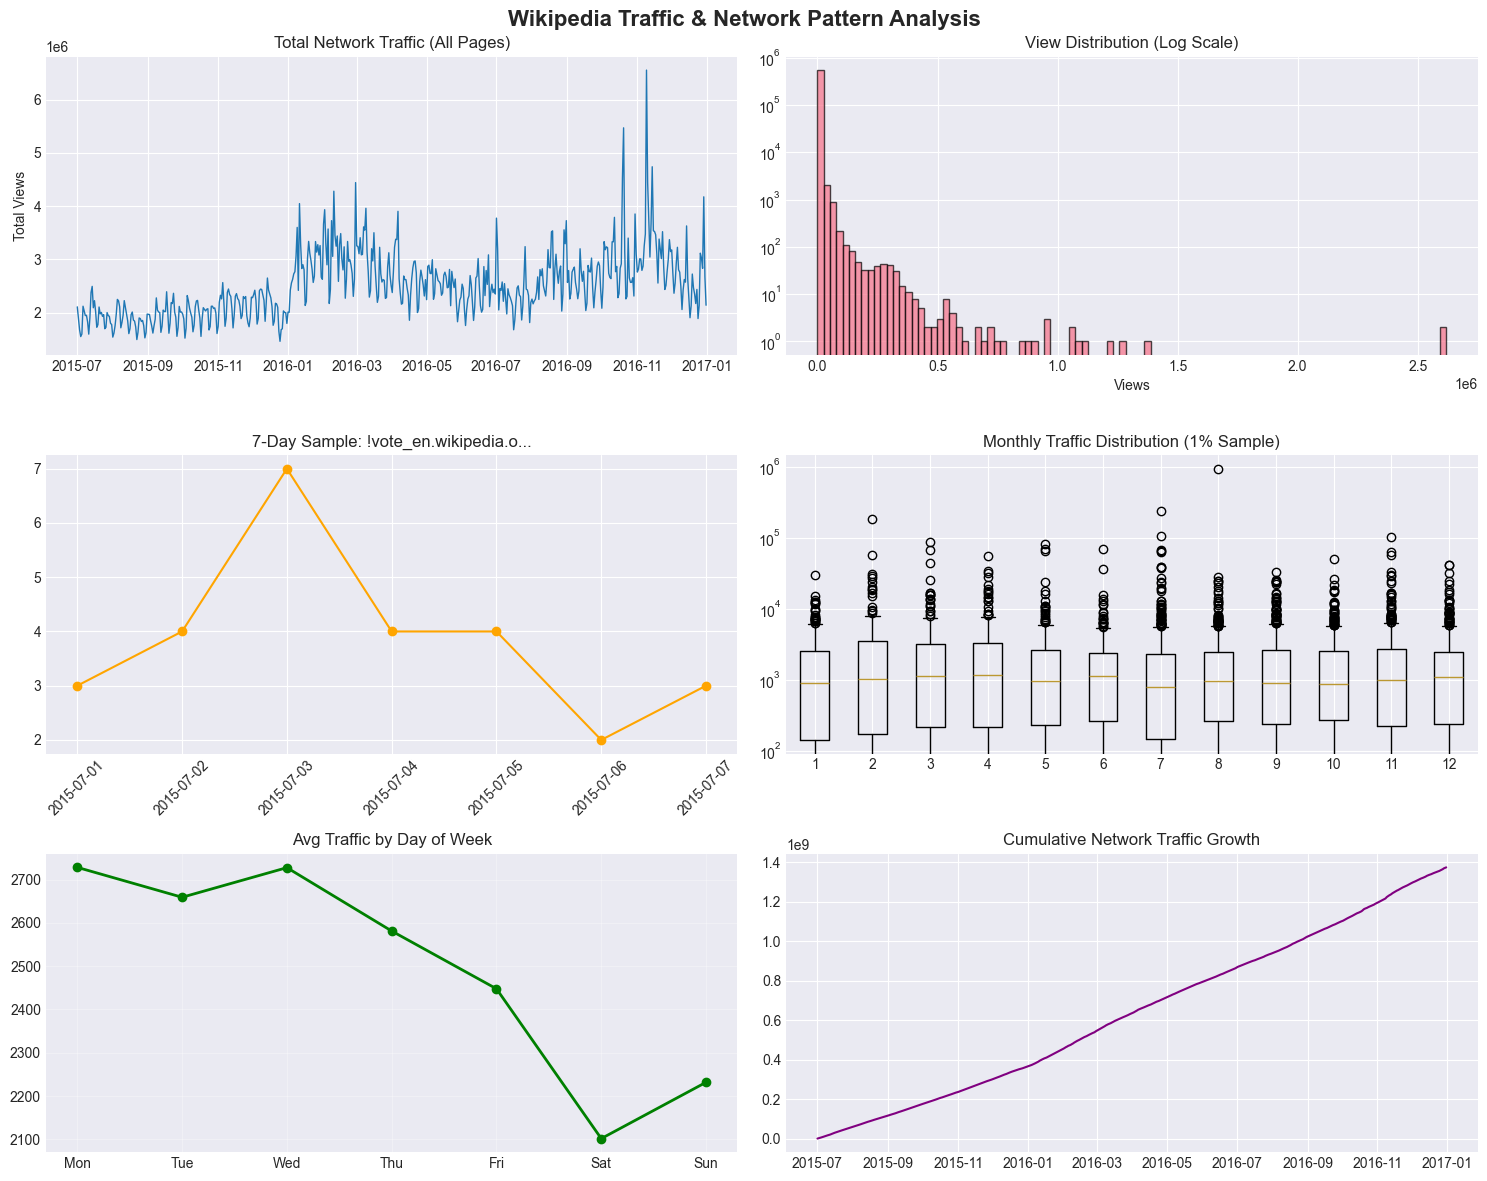

In [3]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Wikipedia Traffic & Network Pattern Analysis', fontsize=16, fontweight='bold')

# 1. Total Network Load (Aggregated views of all pages)
network_total = df.groupby(level=0)['views'].sum()
axes[0, 0].plot(network_total.index, network_total.values, linewidth=1, color='#1f77b4')
axes[0, 0].set_title('Total Network Traffic (All Pages)')
axes[0, 0].set_ylabel('Total Views')

# 2. Distribution of values (Using Log Scale for the massive outliers)
axes[0, 1].hist(df['views'].dropna(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('View Distribution (Log Scale)')
axes[0, 1].set_xlabel('Views')
axes[0, 1].set_yscale('log') # Vital for your 67M max outlier

# 3. One week sample (Pick one specific page to see daily pattern)
sample_page = df['Page'].iloc[0]
week_sample = df[df['Page'] == sample_page].head(7)
axes[1, 0].plot(week_sample.index, week_sample['views'], marker='o', color='orange')
axes[1, 0].set_title(f'7-Day Sample: {sample_page[:20]}...')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Box plot by month
df['month'] = df.index.month
# We sample a fraction of data for the boxplot to save RAM
monthly_data = [df[df['month'] == m]['views'].sample(frac=0.01).dropna().values for m in range(1, 13)]
axes[1, 1].boxplot(monthly_data, tick_labels=[str(m) for m in range(1, 13)])
axes[1, 1].set_title('Monthly Traffic Distribution (1% Sample)')
axes[1, 1].set_yscale('log')

# 5. Day of week pattern
df['dayofweek'] = df.index.dayofweek
daily_avg = df.groupby('dayofweek')['views'].mean()
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[2, 0].plot(days, daily_avg.values, marker='o', color='green', linewidth=2)
axes[2, 0].set_title('Avg Traffic by Day of Week')
axes[2, 0].grid(True, alpha=0.3)

# 6. Cumulative Growth (Trend Analysis)
axes[2, 1].plot(network_total.index, network_total.cumsum(), color='purple')
axes[2, 1].set_title('Cumulative Network Traffic Growth')

plt.tight_layout()
plt.show()

---

## Section 3: Feature Extraction Functions

Now let's create temporal features that will help our model understand time-based patterns.

In [5]:
def extract_temporal_features(df, timestamp_col='timestamp'):
    """
    Extract comprehensive temporal features from timestamp column.

    This function creates features that capture different time scales:
    - Hour: Captures intraday patterns
    - Day of week: Captures weekly patterns
    - Month: Captures seasonal patterns
    - Quarter: Captures broader seasonal trends
    """

    # Make a copy to avoid modifying original
    df_features = df.copy()

    # Extract basic temporal features
    # 2. Extract Temporal Features from the Index
    # Note: .isocalendar().week returns a series, we cast to int
    df_features['dayofweek'] = df_features.index.dayofweek
    df_features['day'] = df_features.index.day
    df_features['month'] = df_features.index.month
    df_features['year'] = df_features.index.year
    #df_features['dayofyear'] = df_features.index.dayofyear
    df_features['weekofyear'] = df_features.index.isocalendar().week.astype(int)

    # 3. Binary Features (Important for identifying "Expected" vs "Unexpected" traffic)
    df_features['is_weekend'] = (df_features['dayofweek'] >= 5).astype(int)
    df_features['is_month_start'] = df_features.index.is_month_start.astype(int)
    df_features['is_month_end'] = df_features.index.is_month_end.astype(int)

    # 4. Cyclical Encoding (The 'Circular' Logic)
    # Helps the model understand that Dec(12) is close to Jan(1)
    df_features['dow_sin'] = np.sin(2 * np.pi * df_features['dayofweek'] / 7)
    df_features['dow_cos'] = np.cos(2 * np.pi * df_features['dayofweek'] / 7)

    df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

    #5. make a temporary database that has the logs so it pairs with the view_logs that we will process later
    temp_log = np.log1p(df_features['views'].fillna(0))

    #6. awarness features: this will give the model context and help it predict spikes better
    grouped = temp_log.groupby(df_features['Page'])

    # Yesterday and Last Week (The "Baseline")
    df_features['lag_1'] = grouped.shift(1)
    df_features['lag_7'] = grouped.shift(7)

    # 7-Day Average (The "Trend")
    df_features['roll_mean_7'] = grouped.transform(lambda x: x.rolling(window=7, min_periods=1).mean())

    #7.page baseline: this allows the model to predict pages based on views and not mistake the page id as a numerical factor.
    df_features['page_baseline'] = temp_log.groupby(df_features['Page']).transform('mean')

    return df_features

# Apply feature extraction
df_with_features = extract_temporal_features(df)

print("Feature Engineering Complete!")
print("-" * 50)
print(f"Original features: {df.shape[1]}")
print(f"Total features now: {df_with_features.shape[1]}")
print("\nNew features created:")
new_features = [col for col in df_with_features.columns if col not in df.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i:2d}. {feat}")

Feature Engineering Complete!
--------------------------------------------------
Original features: 4
Total features now: 18

New features created:
   1. day
   2. year
   3. weekofyear
   4. is_weekend
   5. is_month_start
   6. is_month_end
   7. dow_sin
   8. dow_cos
   9. month_sin
  10. month_cos
  11. lag_1
  12. lag_7
  13. roll_mean_7
  14. page_baseline


---

## Section 4: Outlier Detection and Missing Value Handling

Data quality is crucial for model performance. Let's clean our data properly.

🔍 Outlier Detection Results (Full Dataset)
--------------------------------------------------
Lower bound: -3527.00
Upper bound: 6481.00
Total Outliers: 36,229
Percentage of data: 6.59%


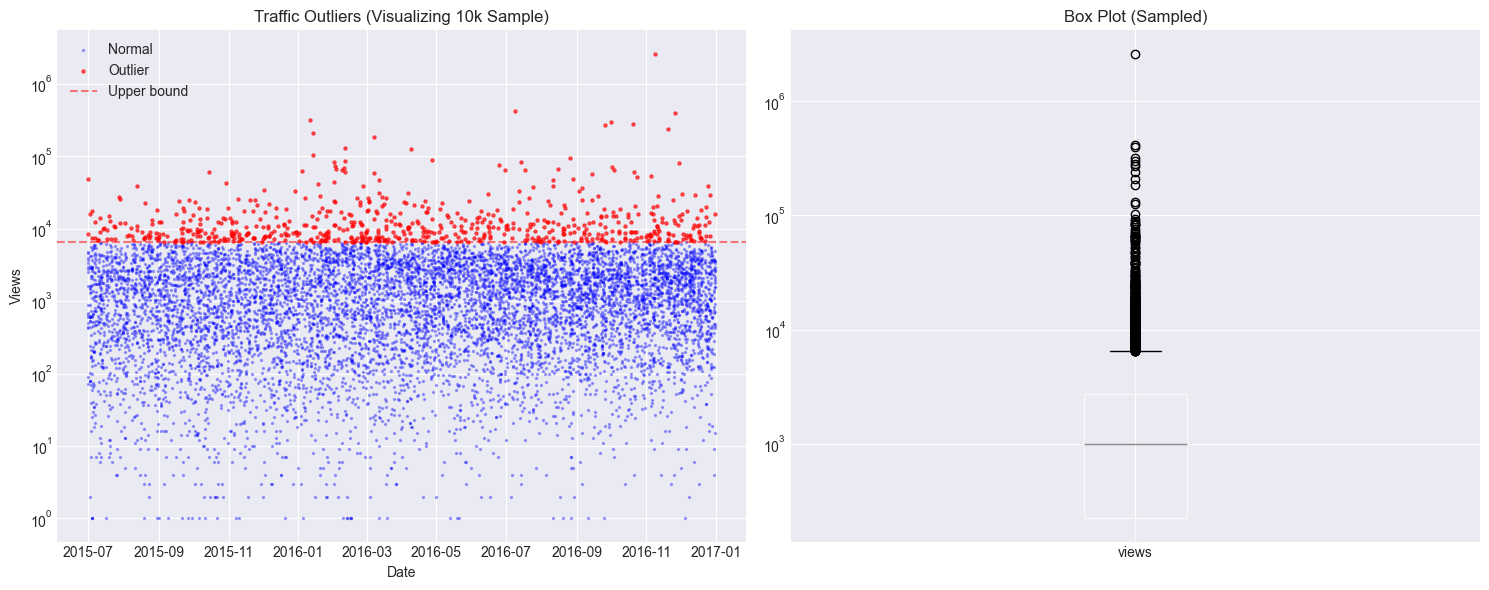

23309

In [6]:
def detect_outliers_iqr(data, column, multiplier=1.5):
    """
    Detect outliers using the Interquartile Range (IQR) method.

    The IQR method is robust and works well for time series data.
    Points beyond Q1 - 1.5*IQR or Q3 + 1.5*IQR are considered outliers.
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR

    outliers = (data[column] < lower_bound) | (data[column] > upper_bound)

    return outliers, lower_bound, upper_bound

# Detect outliers

full_outliers, lower_bound, upper_bound = detect_outliers_iqr(df_with_features, 'views')
n_outliers = full_outliers.sum()

print("🔍 Outlier Detection Results (Full Dataset)")
print("-" * 50)
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Total Outliers: {n_outliers:,}")
print(f"Percentage of data: {n_outliers/len(df_with_features)*100:.2f}%")

#Take a sample for visualization to prevent RAM crashes
sample_df = df_with_features.sample(n=10000).sort_index()

# This ensures the True/False mask matches the sample_df index length
sample_is_outlier = (sample_df['views'] < lower_bound) | (sample_df['views'] > upper_bound)

# Visualize outliers
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
# Use the sample-specific mask to split the data
normal_points = sample_df[~sample_is_outlier]
outlier_points = sample_df[sample_is_outlier]

plt.scatter(normal_points.index, normal_points['views'],
            color='blue', alpha=0.3, s=2, label='Normal')
plt.scatter(outlier_points.index, outlier_points['views'],
            color='red', alpha=0.6, s=5, label='Outlier')

plt.axhline(y=upper_bound, color='r', linestyle='--', alpha=0.5, label='Upper bound')
plt.yscale('log')
plt.title('Traffic Outliers (Visualizing 10k Sample)')
plt.xlabel('Date')
plt.ylabel('Views')
plt.legend()

# Subplot 2: Box Plot
plt.subplot(1, 2, 2)
sample_df.boxplot(column='views', ax=plt.gca())
plt.title('Box Plot (Sampled)')
plt.yscale('log')

plt.tight_layout()
plt.show()

del sample_df
gc.collect()


In [7]:
def handle_missing_values(df, target_col):
    """
    Handle missing values using various strategies.

    For time series, interpolation often works better than simple mean imputation
    because it preserves temporal patterns.
    """
    df_clean = df.copy()

    # 2. Handle Missing Values (Forward Fill + Backward Fill)
    # This preserves the 'last known state' of the network
    n_missing_before = df_clean[target_col].isna().sum()
    df_clean[target_col] = df_clean[target_col].ffill().bfill()
    n_missing_after = df_clean[target_col].isna().sum()

    print(f"🛠️ Missing values handled: {n_missing_before:,} -> {n_missing_after:,}")

    if target_col == 'views':
      df_clean['views_log'] = np.log1p(df_clean[target_col])

      # 3. Cap Outliers (Clipping to the Upper Bound)
      # This prevents the 2-million-view spikes from drowning out the model's logic
      # Note: We use .loc and the 'outliers' mask we found in the previous step

      df_clean.loc[full_outliers, target_col] = np.clip(
          df_clean.loc[full_outliers, target_col],
          lower_bound,
          upper_bound
      )
      print(f"🚀 Outliers capped at {upper_bound:.2f}")

      # 4. Log Transformation (The 'Great Equalizer')
      df_clean['views_log'] = np.log1p(df_clean[target_col])

      print(f"Missing values before: {n_missing_before}")
      print(f"Missing values after: {n_missing_after}")

    return df_clean

# Handle missing values
print("Handling Missing Values")
print("-" * 50)
df_clean = handle_missing_values(df_with_features, 'views')

#clean the lag features since they are based on views
df_clean['lag_1'] = handle_missing_values(df_clean, 'lag_1')['lag_1']
df_clean['lag_7'] = handle_missing_values(df_clean, 'lag_7')['lag_7']
df_clean['roll_mean_7'] = handle_missing_values(df_clean, 'roll_mean_7')['roll_mean_7']
df_clean['page_baseline'] = handle_missing_values(df_clean, 'page_baseline')['page_baseline']

# Optional: Cap outliers instead of removing them
# This preserves the temporal structure of the data
df_clean.loc[full_outliers, 'views'] = np.clip(
    df_clean.loc[full_outliers, 'views'],
    lower_bound,
    upper_bound
)


print(f"\nData cleaning complete! Outliers have been capped to bounds.")

Handling Missing Values
--------------------------------------------------
🛠️ Missing values handled: 0 -> 0
🚀 Outliers capped at 6481.00
Missing values before: 0
Missing values after: 0
🛠️ Missing values handled: 1,000 -> 0
🛠️ Missing values handled: 7,000 -> 0
🛠️ Missing values handled: 0 -> 0
🛠️ Missing values handled: 0 -> 0

Data cleaning complete! Outliers have been capped to bounds.


---

## Section 5: Time Series Splitting Implementation

Proper splitting is crucial for time series - we must respect temporal order!

Time Series Split Information
--------------------------------------------------
Total samples: 550,000
Training samples: 440,000 (80.0%)
Gap samples: 0
Test samples: 110,000 (20.0%)

Training period: 2015-07-01 00:00:00 to 2016-09-12 00:00:00
Testing period: 2016-09-13 00:00:00 to 2016-12-31 00:00:00


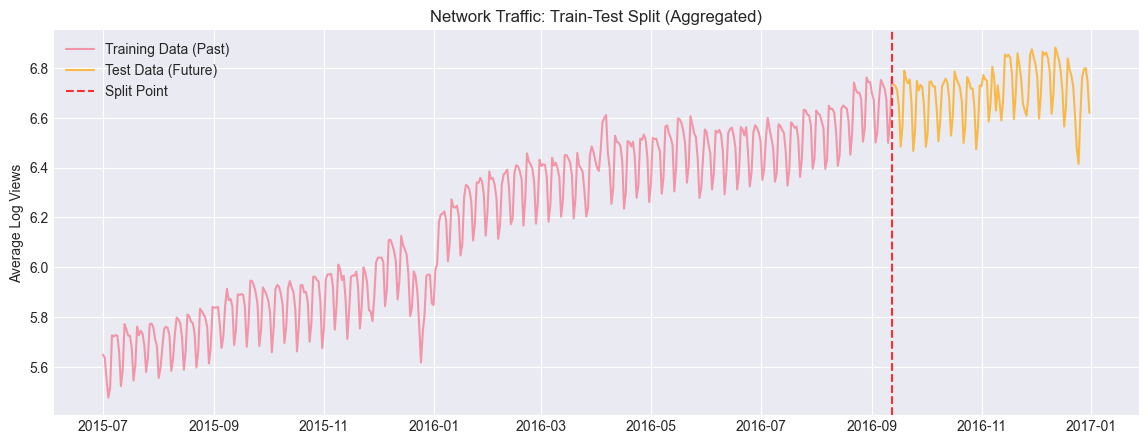

In [8]:
def time_series_train_test_split(df, test_size=0.2, gap=0):
    """
    Split time series data into train and test sets while preserving temporal order.

    CRITICAL: Never use random splitting for time series!
    We train on past data and test on future data.

    Parameters:
    - df: DataFrame with temporal order
    - test_size: Fraction of data to use for testing
    - gap: Optional gap between train and test (to simulate deployment lag)
    """
    df_sorted = df.sort_index()

    n = len(df_sorted)
    test_size_n = int(n * test_size)
    train_size_n = n - test_size_n - gap

    train_df = df_sorted.iloc[:train_size_n].copy()
    test_df = df_sorted.iloc[train_size_n + gap:].copy()

    print("Time Series Split Information")
    print("-" * 50)
    print(f"Total samples: {n:,}")
    print(f"Training samples: {len(train_df):,} ({len(train_df)/n*100:.1f}%)")
    print(f"Gap samples: {gap}")
    print(f"Test samples: {len(test_df):,} ({len(test_df)/n*100:.1f}%)")
    print(f"\nTraining period: {train_df.index.min()} to {train_df.index.max()}")
    print(f"Testing period: {test_df.index.min()} to {test_df.index.max()}")

    return train_df, test_df

# Split the data
train_df, test_df = time_series_train_test_split(df_clean, test_size=0.2)

# Visualize the split
plt.figure(figsize=(14, 5))
# Aggregating by date for a cleaner "Network-Wide" view of the split
plt.plot(train_df.groupby(level=0)[ 'views_log'].mean(), label='Training Data (Past)', alpha=0.7)
plt.plot(test_df.groupby(level=0)['views_log'].mean(), label='Test Data (Future)', alpha=0.7, color='orange')
plt.axvline(x=train_df.index.max(), color='red', linestyle='--', alpha=0.8, label='Split Point')

plt.title('Network Traffic: Train-Test Split (Aggregated)')
plt.ylabel('Average Log Views')
plt.legend()
plt.show()

In [9]:
feature_columns = [
    'dayofweek', 'day', 'weekofyear',
    'is_weekend', 'is_month_start', 'is_month_end',
    'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'lag_1', 'lag_7', 'roll_mean_7','page_baseline'
]


X_train = train_df[feature_columns]
y_train = train_df['views_log']

X_test = test_df[feature_columns]
y_test = test_df['views_log']

print("🚀 Feature Matrix Ready!")
print("-" * 30)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Target: views_log")

🚀 Feature Matrix Ready!
------------------------------
X_train shape: (440000, 14)
X_test shape: (110000, 14)
Target: views_log


---

## Section 6: Model Training Pipeline

Time to build our baseline linear regression model!

Training Baseline Model
--------------------------------------------------
Model training complete!

Top 5 Most Important Features (by coefficient magnitude):
          Feature  Coefficient
12    roll_mean_7     1.741556
10          lag_1     0.677340
11          lag_7    -0.110197
3      is_weekend    -0.090624
13  page_baseline     0.065510


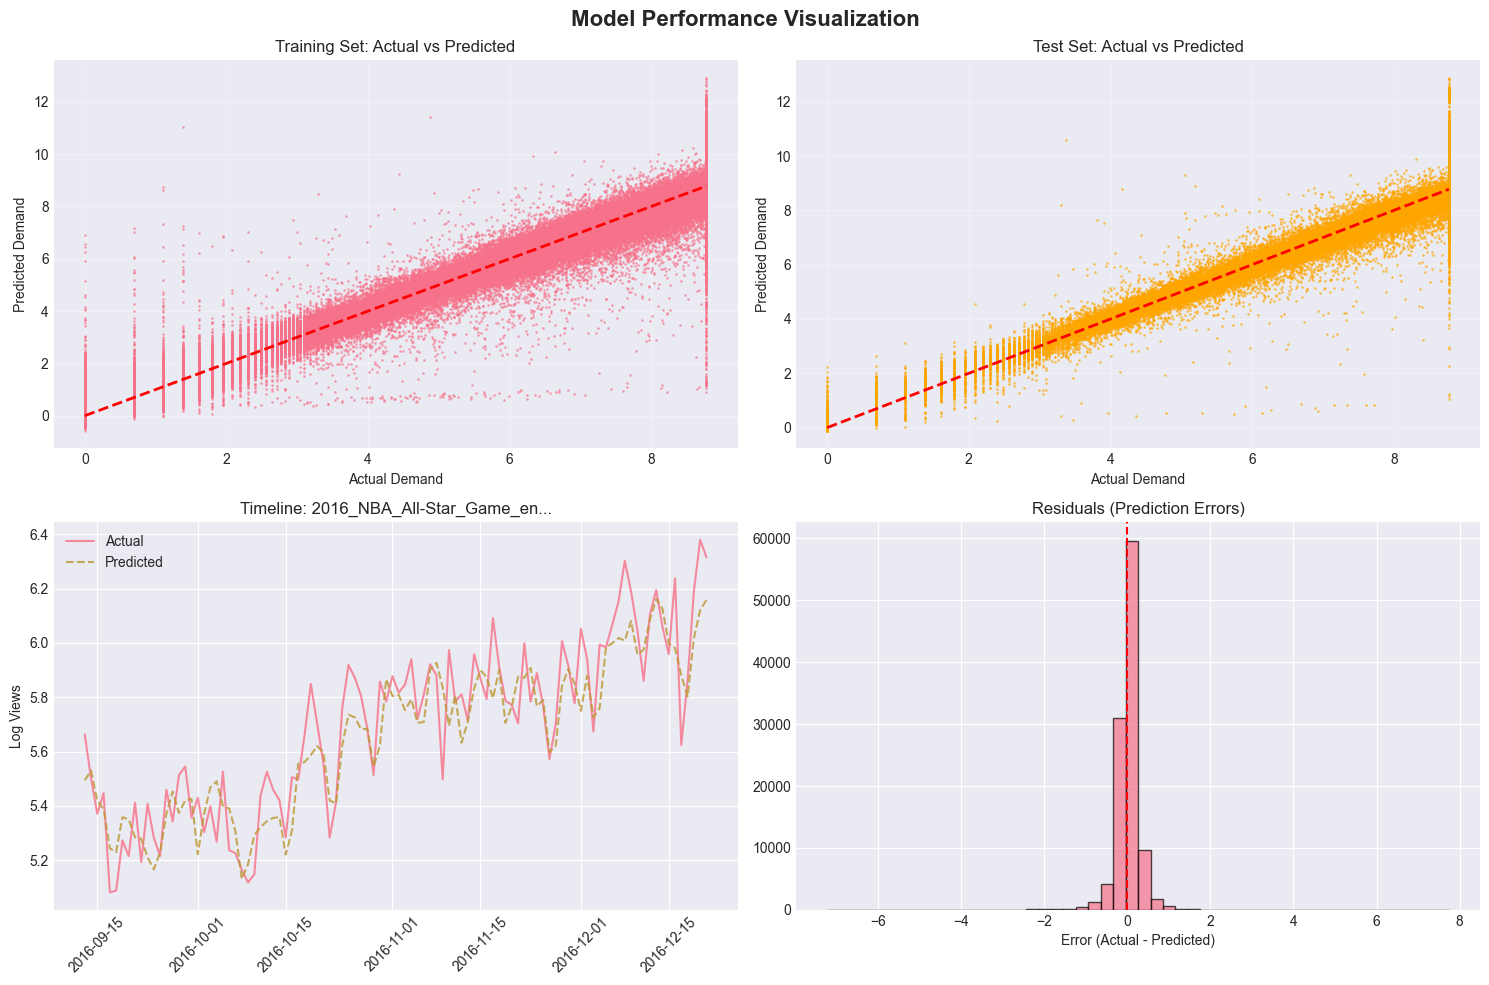

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def create_baseline_pipeline():
    """
    Create a scikit-learn pipeline for our baseline model.

    A pipeline ensures that all preprocessing steps are applied
    consistently to both training and test data.
    """

    pipeline = Pipeline([
        ('scaler', StandardScaler()),  # Normalize features
        ('regressor', LinearRegression())  # Linear regression model
    ])

    return pipeline

# Create and train the model
print("Training Baseline Model")
print("-" * 50)

baseline_model = create_baseline_pipeline()

# Train the model
baseline_model.fit(X_train, y_train)

# Make predictions
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

print("Model training complete!")

# Get model coefficients
regressor = baseline_model.named_steps['regressor']
coefficients = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': regressor.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 5 Most Important Features (by coefficient magnitude):")
print(coefficients.head())

# Visualize predictions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Model Performance Visualization', fontsize=16, fontweight='bold')

# 1. Training set predictions
axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, s=1)
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Demand')
axes[0, 0].set_ylabel('Predicted Demand')
axes[0, 0].set_title('Training Set: Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# 2. Test set predictions
axes[0, 1].scatter(y_test, y_test_pred, alpha=0.5, s=1, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Demand')
axes[0, 1].set_ylabel('Predicted Demand')
axes[0, 1].set_title('Test Set: Actual vs Predicted')
axes[0, 1].grid(True, alpha=0.3)

# 3. Time series plot - test set
#We pick a specific page to look at so the data is readable
sample_page = test_df['Page'].iloc[0]
page_mask = test_df['Page'] == sample_page

# Using .index because there is no 'timestamp' column
# Indexing y_test_pred via the same mask to keep lengths consistent
axes[1, 0].plot(test_df[page_mask].index[:100], y_test[page_mask][:100],
               label='Actual', alpha=0.8)
axes[1, 0].plot(test_df[page_mask].index[:100], y_test_pred[page_mask.values][:100],
               label='Predicted', alpha=0.8, linestyle='--')

axes[1, 0].set_title(f'Timeline: {sample_page[:25]}...')
axes[1, 0].set_ylabel('Log Views')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()

# 4. Residuals distribution (Altered title)
residuals = y_test - y_test_pred
axes[1, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Error (Actual - Predicted)')
axes[1, 1].set_title('Residuals (Prediction Errors)')

plt.tight_layout()
plt.show()

---

## Section 7: Evaluation Metric Calculations

Let's calculate MAE and MAPE to understand our model's performance.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_metrics(y_true, y_pred):
    """
    Calculate comprehensive evaluation metrics for time series forecasting.

    MAE: Average absolute error - easy to interpret
    MAPE: Percentage error - good for comparing across different scales
    RMSE: Penalizes large errors more
    R²: Proportion of variance explained
    """

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # MAPE calculation (avoid division by zero)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # Additional business metrics
    residuals = y_true - y_pred
    max_error = np.max(np.abs(residuals))
    std_error = np.std(residuals)

    return {
        'MAE': mae,
        'MAPE': mape,
        'RMSE': rmse,
        'R²': r2,
        'Max Error': max_error,
        'Std Error': std_error
    }

# Calculate metrics for both sets
train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

# Display results
print("Model Performance Metrics")
print("=" * 60)
print(f"{'Metric':<15} {'Training':>15} {'Test':>15} {'Difference':>15}")
print("-" * 60)

for metric in train_metrics.keys():
    train_val = train_metrics[metric]
    test_val = test_metrics[metric]
    diff = test_val - train_val
    print(f"{metric:<15} {train_val:>14.3f} {test_val:>14.3f} {diff:>14.3f}")

# Interpretation guidelines
print("\nInterpretation Guidelines:")
print("-" * 60)
print(f"MAE = {test_metrics['MAE']:.2f}: On average, predictions are off by {test_metrics['MAE']:.2f} units")
print(f"MAPE = {test_metrics['MAPE']:.2f}%: Average percentage error in predictions")
print(f"R² = {test_metrics['R²']:.3f}: Model explains {test_metrics['R²']*100:.1f}% of variance")

# Operational thresholds
mae_threshold = 10  # Example threshold
if test_metrics['MAE'] < mae_threshold:
    print(f"\nMAE is below operational threshold of {mae_threshold} (This is an acceptable performance in production)")
else:
    print(f"\nMAE exceeds operational threshold of {mae_threshold} (This is not an acceptable performance in production)")

Model Performance Metrics
Metric                 Training            Test      Difference
------------------------------------------------------------
MAE                      0.192          0.192         -0.000
MAPE                     3.599          3.174         -0.425
RMSE                     0.343          0.343          0.000
R²                       0.979          0.960         -0.020
Max Error                9.641          7.740         -1.901
Std Error                0.343          0.342         -0.001

Interpretation Guidelines:
------------------------------------------------------------
MAE = 0.19: On average, predictions are off by 0.19 units
MAPE = 3.17%: Average percentage error in predictions
R² = 0.960: Model explains 96.0% of variance

MAE is below operational threshold of 10 (This is an acceptable performance in production)


That looks pretty good but its important to keep in mind that we are using log transform to compress the data into an easy to understand format. What would it look like if we saw the raw calculations?

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def calculate_raw_metrics(y_true_log, y_pred_log):
    """
    Calculate comprehensive evaluation metrics for time series forecasting.

    MAE: Average absolute error - easy to interpret
    MAPE: Percentage error - good for comparing across different scales
    RMSE: Penalizes large errors more
    R²: Proportion of variance explained
    """

    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)

    # Force no negative views (Linear Regression sometimes predicts < 0)
    y_pred_raw = np.maximum(y_pred_raw, 0)

    # 2. Calculate Real-World Metrics
    mae_raw = mean_absolute_error(y_true_raw, y_pred_raw)
    rmse_raw = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))

    # True Percentage Error (MAPE)
    mask = y_true_raw > 0
    mape_raw = np.mean(np.abs((y_true_raw[mask] - y_pred_raw[mask]) / y_true_raw[mask])) * 100

    return {
        'MAE (Real Views)': mae_raw,
        'RMSE (Real Views)': rmse_raw,
        'MAPE (%)': mape_raw,
        'Max Error (Views)': np.max(np.abs(y_true_raw - y_pred_raw))
    }

# Calculate metrics for both sets
raw_train_metrics = calculate_raw_metrics(y_train, y_train_pred)
raw_test_metrics = calculate_raw_metrics(y_test, y_test_pred)

# Display results
print("Model Performance Metrics")
print("=" * 60)
print(f"{'Metric':<15} {'Training':>15} {'Test':>15} {'Difference':>15}")
print("-" * 60)

for metric in raw_train_metrics.keys():
    train_val = raw_train_metrics[metric]
    test_val = raw_test_metrics[metric]
    diff = test_val - train_val
    print(f"{metric:<15} {train_val:>14.3f} {test_val:>14.3f} {diff:>14.3f}")

# Interpretation guidelines
print("\nInterpretation Guidelines:")
print("-" * 60)
print(f"MAE = {raw_test_metrics['MAE (Real Views)']:.2f}: On average, predictions are off by {raw_test_metrics['MAE (Real Views)']:.2f} units")
print(f"MAPE = {raw_test_metrics['MAPE (%)']:.2f}%: Average percentage error in predictions")
print(f"R² = {test_metrics['R²']:.3f}: Model explains {test_metrics['R²']*100:.1f}% of variance")
#print(f"R² = {test_metrics['R²']:.3f}: Model explains {test_metrics['R²']*100:.1f}% of variance")

# Operational thresholds
mae_threshold = 1000  #threshold for raw(take in mind that some amount of views is in the millions)
if raw_test_metrics['MAE (Real Views)'] < mae_threshold:
    print(f"\nMAE is below operational threshold of {mae_threshold} (This is an acceptable performance in production)")
else:
    print(f"\nMAE exceeds operational threshold of {mae_threshold} (This is not an acceptable performance in production)")

Model Performance Metrics
Metric                 Training            Test      Difference
------------------------------------------------------------
MAE (Real Views)        549.328        754.410        205.082
RMSE (Real Views)       3449.874       7167.307       3717.434
MAPE (%)                31.215         25.521         -5.694
Max Error (Views)     395939.207     382380.601     -13558.606

Interpretation Guidelines:
------------------------------------------------------------
MAE = 754.41: On average, predictions are off by 754.41 units
MAPE = 25.52%: Average percentage error in predictions
R² = 0.960: Model explains 96.0% of variance

MAE is below operational threshold of 1000 (This is an acceptable performance in production)


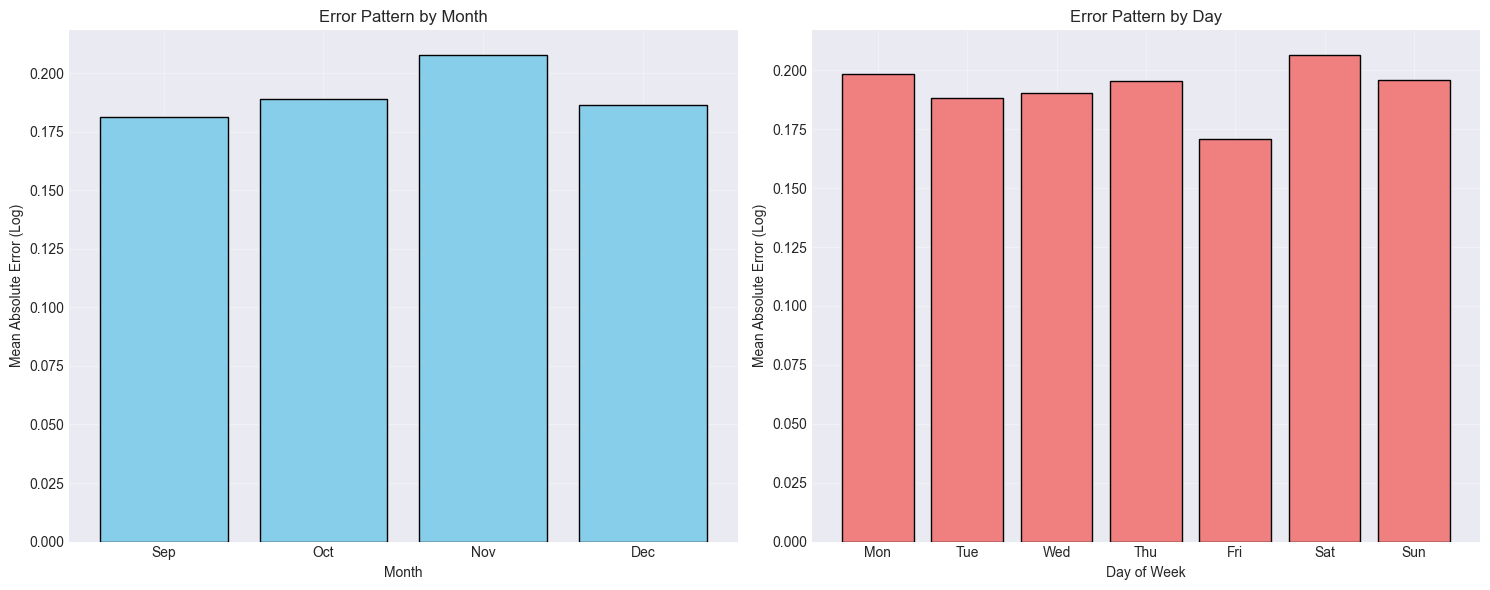

📈 Error Analysis Insights (Log-Scale)
--------------------------------------------------
Highest error month: Nov (MAE: 0.21)
Highest error day:   Sat (MAE: 0.21)
Lowest error day:    Fri (MAE: 0.17)


In [13]:
# Error analysis by time components
test_df['predictions_log'] = y_test_pred
test_df['error_log'] = y_test - y_test_pred
test_df['abs_error_log'] = np.abs(test_df['error_log'])

# 2. Group Errors by Month and Day of Week
# (Removed 'hour' because Wikipedia daily data doesn't have it)
monthly_errors = test_df.groupby('month')['abs_error_log'].mean()
daily_errors = test_df.groupby('dayofweek')['abs_error_log'].mean()

# 3. Visualize Error Patterns
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Error by Month
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
# Ensure we only plot months present in the test set (likely Sep-Dec)
present_months = [months[i-1] for i in monthly_errors.index]

axes[0].bar(monthly_errors.index, monthly_errors.values, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Mean Absolute Error (Log)')
axes[0].set_title('Error Pattern by Month')
axes[0].set_xticks(monthly_errors.index)
axes[0].set_xticklabels(present_months)
axes[0].grid(True, alpha=0.3)

# Subplot 2: Error by Day of Week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].bar(range(7), daily_errors.values, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Mean Absolute Error (Log)')
axes[1].set_title('Error Pattern by Day')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(days)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Print Insights
print("📈 Error Analysis Insights (Log-Scale)")
print("-" * 50)
print(f"Highest error month: {months[int(monthly_errors.idxmax())-1]} (MAE: {monthly_errors.max():.2f})")
print(f"Highest error day:   {days[daily_errors.idxmax()]} (MAE: {daily_errors.max():.2f})")
print(f"Lowest error day:    {days[daily_errors.idxmin()]} (MAE: {daily_errors.min():.2f})")

## Section 2 of Unit 13: Errors


In [14]:
def calculate_forecast_errors(y_true_log, y_pred_log):
    """
    Generate absolute percentage errors for classification
    """
    y_true_raw = np.expm1(y_true_log)
    y_pred_raw = np.expm1(y_pred_log)

    y_pred_raw = np.maximum(y_pred_raw, 0)


    # Avoid division by zero
    mask = y_true_raw != 0

    # Calculate absolute percentage error
    ape = np.abs((y_true_raw - y_pred_raw) / y_true_raw) * 100

    # Handle zero values appropriately for your domain
    ape[~mask] = np.abs(y_pred_raw[~mask])  # Or another domain-appropriate handling

    # Validate errors
    print(f"Error Statistics:")
    print(f"Mean APE: {ape.mean():.2f}%")
    print(f"Median APE: {np.median(ape):.2f}%")
    print(f"95th percentile: {np.percentile(ape, 95):.2f}%")

    return ape

# Example usage
train_errors = calculate_forecast_errors(y_train, y_train_pred)
test_errors = calculate_forecast_errors(y_test, y_test_pred)
all_errors = np.concatenate([train_errors, test_errors])


Error Statistics:
Mean APE: 28.83%
Median APE: 10.28%
95th percentile: 61.97%
Error Statistics:
Mean APE: 25.11%
Median APE: 11.63%
95th percentile: 58.62%


##Section 3 of Unit 13: Binary Labels of Crisis

Crisis Distribution:
Total samples: 550000
Crisis events: 84273 (15.3%)
Normal events: 465727 (84.7%)


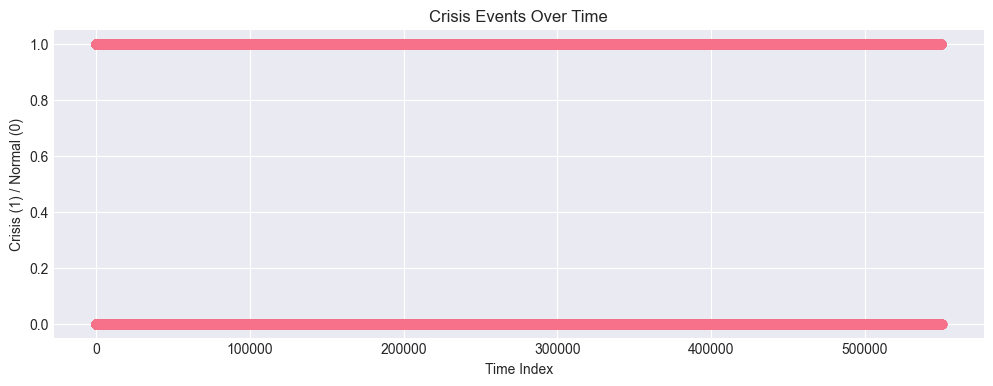

In [15]:
def create_crisis_labels(errors, threshold):
    """
    Convert continuous errors to binary crisis labels
    """
    # Create binary labels
    crisis_labels = (errors > threshold).astype(int)

    # Analyze distribution
    n_crisis = crisis_labels.sum()
    n_total = len(crisis_labels)
    crisis_rate = (n_crisis / n_total) * 100

    print(f"Crisis Distribution:")
    print(f"Total samples: {n_total}")
    print(f"Crisis events: {n_crisis} ({crisis_rate:.1f}%)")
    print(f"Normal events: {n_total - n_crisis} ({100-crisis_rate:.1f}%)")

    # Verify temporal distribution
    plt.figure(figsize=(12, 4))
    plt.scatter(range(len(crisis_labels)), crisis_labels, alpha=0.5)
    plt.title('Crisis Events Over Time')
    plt.xlabel('Time Index')
    plt.ylabel('Crisis (1) / Normal (0)')
    plt.show()

    return crisis_labels

# Example usage
crisis_labels = create_crisis_labels(all_errors, threshold=30.0)


In [16]:
# Now we make the dataFrame that has accurate errors
df_rf = df.copy()
df_rf['Crisis_Label'] = crisis_labels

##Section 4 unit 13: Feature Engineering

In [17]:
def extract_temporal_features_rf(df, timestamp_col='timestamp'):
    """
    Extract comprehensive temporal features from timestamp column.

    This function creates features that capture different time scales:
    - Hour: Captures intraday patterns
    - Day of week: Captures weekly patterns
    - Month: Captures seasonal patterns
    - Quarter: Captures broader seasonal trends
    """

    # Make a copy to avoid modifying original
    df_features = df.copy()

    # Extract basic temporal features
    # 2. Extract Temporal Features from the Index
    # Note: .isocalendar().week returns a series, we cast to int
    df_features['dayofweek'] = df_features.index.dayofweek
    df_features['day'] = df_features.index.day
    df_features['month'] = df_features.index.month
    df_features['year'] = df_features.index.year
    #df_features['dayofyear'] = df_features.index.dayofyear
    df_features['weekofyear'] = df_features.index.isocalendar().week.astype(int)

    # 3. Binary Features (Important for identifying "Expected" vs "Unexpected" traffic)
    df_features['is_weekend'] = (df_features['dayofweek'] >= 5).astype(int)
    df_features['is_month_start'] = df_features.index.is_month_start.astype(int)
    df_features['is_month_end'] = df_features.index.is_month_end.astype(int)

    # 4. Cyclical Encoding (The 'Circular' Logic)
    # Helps the model understand that Dec(12) is close to Jan(1)
    df_features['dow_sin'] = np.sin(2 * np.pi * df_features['dayofweek'] / 7)
    df_features['dow_cos'] = np.cos(2 * np.pi * df_features['dayofweek'] / 7)

    df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12)
    df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12)

    #5. make a temporary database that has the logs so it pairs with the view_logs that we will process later
    temp_log = np.log1p(df_features['views'].fillna(0))

    #6. awarness features: this will give the model context and help it predict spikes better
    grouped = temp_log.groupby(df_features['Page'])

    # Yesterday and Last Week (The "Baseline")
    df_features['lag_1'] = grouped.shift(1)
    df_features['lag_7'] = grouped.shift(7)

    # 7-Day Average (The "Trend")
    df_features['roll_mean_7'] = grouped.transform(lambda x: x.rolling(window=7, min_periods=1).mean())

    #7.page baseline: this allows the model to predict pages based on views and not mistake the page id as a numerical factor.
    df_features['page_baseline'] = temp_log.groupby(df_features['Page']).transform('mean')

    # Additions for the Random Forest Model
    # 1. Stability Measure: How 'choppy' is the traffic lately?
    df_features['traffic_volatility'] = grouped.transform(lambda x: x.rolling(window=7, min_periods=1).std())

    # 2. Surge Detector: Comparing today's log-growth vs. the weekly average
    # (High positive values suggest an unexpected spike)
    df_features['surge_momentum'] = (temp_log - df_features['roll_mean_7'])

    # 3. Deviation: How far are we from the monthly 'normal'?
    roll_mean_28 = grouped.transform(lambda x: x.rolling(window=28, min_periods=1).mean())
    df_features['monthly_deviation'] = temp_log - roll_mean_28

    # 4. Weekend Momentum (Interaction)
    # Often, crises happen when weekend surges are higher than expected
    df_features['weekend_intensity'] = df_features['is_weekend'] * df_features['surge_momentum']

    return df_features

# Apply feature extraction
df_with_features_rf = extract_temporal_features_rf(df_rf)

print("Feature Engineering Complete!")
print("-" * 50)
print(f"Original features: {df.shape[1]}")
print(f"Total features now: {df_with_features_rf.shape[1]}")
print("\nNew features created:")
new_features = [col for col in df_with_features_rf.columns if col not in df.columns]
for i, feat in enumerate(new_features, 1):
    print(f"  {i:2d}. {feat}")

Feature Engineering Complete!
--------------------------------------------------
Original features: 4
Total features now: 23

New features created:
   1. Crisis_Label
   2. day
   3. year
   4. weekofyear
   5. is_weekend
   6. is_month_start
   7. is_month_end
   8. dow_sin
   9. dow_cos
  10. month_sin
  11. month_cos
  12. lag_1
  13. lag_7
  14. roll_mean_7
  15. page_baseline
  16. traffic_volatility
  17. surge_momentum
  18. monthly_deviation
  19. weekend_intensity


##Section 4.5 of unit 13: Cleaning the Data
Now that we have a new dataframe with new features we should make sure to clean the data.

In [18]:
def handle_missing_values_rf(df, target_col):
    """
    Handle missing values using various strategies.

    For time series, interpolation often works better than simple mean imputation
    because it preserves temporal patterns.
    """
    df_clean = df.copy()

    # 2. Handle Missing Values (Forward Fill + Backward Fill)
    # This preserves the 'last known state' of the network
    n_missing_before = df_clean[target_col].isna().sum()
    df_clean[target_col] = df_clean[target_col].ffill().bfill()
    n_missing_after = df_clean[target_col].isna().sum()

    print(f"🛠️ Missing values handled: {n_missing_before:,} -> {n_missing_after:,}")

    if target_col == 'views':
      df_clean['views_log'] = np.log1p(df_clean[target_col])

      # 4. Log Transformation (The 'Great Equalizer')
      df_clean['views_log'] = np.log1p(df_clean[target_col])

      print(f"Missing values before: {n_missing_before}")
      print(f"Missing values after: {n_missing_after}")

    return df_clean

# Handle missing values
print("Handling Missing Values")
print("-" * 50)
df_clean_rf = handle_missing_values_rf(df_with_features_rf, 'views')

#clean the lag features since they are based on views
df_clean_rf['lag_1'] = handle_missing_values_rf(df_clean_rf, 'lag_1')['lag_1']
df_clean_rf['lag_7'] = handle_missing_values_rf(df_clean_rf, 'lag_7')['lag_7']
df_clean_rf['roll_mean_7'] = handle_missing_values_rf(df_clean_rf, 'roll_mean_7')['roll_mean_7']
df_clean_rf['page_baseline'] = handle_missing_values_rf(df_clean_rf, 'page_baseline')['page_baseline']
df_clean_rf['traffic_volatility'] = handle_missing_values_rf(df_clean_rf, 'traffic_volatility')['traffic_volatility']
df_clean_rf['surge_momentum'] = handle_missing_values_rf(df_clean_rf, 'surge_momentum')['surge_momentum']
df_clean_rf['monthly_deviation'] = handle_missing_values_rf(df_clean_rf, 'monthly_deviation')['monthly_deviation']
df_clean_rf['weekend_intensity'] = handle_missing_values_rf(df_clean_rf, 'weekend_intensity')['weekend_intensity']

df_final_rf = df_clean_rf.dropna()

print(f"\nData cleaning complete! Outliers have been untouched.")

Handling Missing Values
--------------------------------------------------
🛠️ Missing values handled: 0 -> 0
Missing values before: 0
Missing values after: 0
🛠️ Missing values handled: 1,000 -> 0
🛠️ Missing values handled: 7,000 -> 0
🛠️ Missing values handled: 0 -> 0
🛠️ Missing values handled: 0 -> 0
🛠️ Missing values handled: 1,000 -> 0
🛠️ Missing values handled: 0 -> 0
🛠️ Missing values handled: 0 -> 0
🛠️ Missing values handled: 0 -> 0

Data cleaning complete! Outliers have been untouched.


##Section 5 unit 13: Time splitting

In [19]:
features = df_final_rf.drop(columns=['Crisis_Label', 'views', 'views_log'])
labels = df_final_rf['Crisis_Label']

In [20]:
def temporal_train_test_split(X, y, train_size=0.6, val_size=0.2):
    """
    Split time series data respecting temporal order
    """
    n_samples = len(X)
    # Add gap to prevent leakage (optional but recommended)
      # 7 day gap for daily data
    gap = 7

    # Calculate split indices
    train_end = int(n_samples * train_size)
    val_start= train_end + gap
    val_end = int(n_samples * (train_size + val_size))
    test_start = val_end + gap

    # Create splits
    X_trainrf = X.iloc[:train_end]
    y_trainrf = y.iloc[:train_end]

    X_valrf = X.iloc[val_start:val_end]
    y_valrf = y.iloc[val_start:val_end]

    X_testrf = X.iloc[test_start:]
    y_testrf = y.iloc[test_start:]


    print(f"Train: {len(X_trainrf)} samples (up to index {train_end})")
    print(f"Val: {len(X_valrf)} samples (indices {train_end+gap} to {val_end})")
    print(f"Test: {len(X_testrf)} samples (from index {val_end+gap})")

    # Verify no overlap
    assert len(set(X_trainrf.index) & set(X_valrf.index)) == 0
    assert len(set(X_valrf.index) & set(X_testrf.index)) == 0

    return X_trainrf, X_valrf, X_testrf, y_trainrf, y_valrf, y_testrf

# Create unique integer IDs for every row
features_reset = features.reset_index(drop=True)
labels_reset = labels.reset_index(drop=True)

# Example usage
X_train_rf, X_val_rf, X_test_rf, y_train_rf, y_val_rf, y_test_rf = temporal_train_test_split(features_reset, labels_reset)

Train: 330000 samples (up to index 330000)
Val: 109993 samples (indices 330007 to 440000)
Test: 109993 samples (from index 440007)


#Section 6: Balancing Technique implementation

In [21]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

def handle_class_imbalance(X_train, y_train, method='smote'):
    """
    Address class imbalance for crisis detection
    """
    # Check initial balance
    unique, counts = np.unique(y_train, return_counts=True)
    print(f"Original distribution: {dict(zip(unique, counts))}")

    if method == 'smote':
        # SMOTE oversampling
        smote = SMOTE(random_state=42, k_neighbors=5)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)

        unique, counts = np.unique(y_balanced, return_counts=True)
        print(f"After SMOTE: {dict(zip(unique, counts))}")

        return X_balanced, y_balanced

    elif method == 'class_weight':
        # Use class weights in the model instead
        n_samples = len(y_train)
        n_classes = len(np.unique(y_train))

        class_weights = {}
        for class_label in np.unique(y_train):
            n_class = np.sum(y_train == class_label)
            class_weights[class_label] = n_samples / (n_classes * n_class)

        print(f"Class weights: {class_weights}")
        return X_train, y_train, class_weights

    elif method == 'undersample':
        # Random undersampling
        from imblearn.under_sampling import RandomUnderSampler
        rus = RandomUnderSampler(random_state=42)
        X_balanced, y_balanced = rus.fit_resample(X_train, y_train)

        unique, counts = np.unique(y_balanced, return_counts=True)
        print(f"After undersampling: {dict(zip(unique, counts))}")

        return X_balanced, y_balanced


#This gets rid of all the string based columns that way SMOTE(which requires only numeric columns) can work
X_train_rf_numeric = X_train_rf.select_dtypes(include=[np.number])
X_val_rf_numeric = X_val_rf.select_dtypes(include=[np.number])
X_test_rf_numeric = X_test_rf.select_dtypes(include=[np.number])

print(f"Removed string columns. Features now: {list(X_train_rf_numeric.columns)}")

# Example usage
X_balanced, y_balanced = handle_class_imbalance(X_train_rf_numeric, y_train_rf, method='smote')


Removed string columns. Features now: ['month', 'dayofweek', 'day', 'year', 'weekofyear', 'is_weekend', 'is_month_start', 'is_month_end', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_1', 'lag_7', 'roll_mean_7', 'page_baseline', 'traffic_volatility', 'surge_momentum', 'monthly_deviation', 'weekend_intensity']
Original distribution: {np.int64(0): np.int64(278936), np.int64(1): np.int64(51064)}
After SMOTE: {np.int64(0): np.int64(278936), np.int64(1): np.int64(278936)}


##Section 7 of Unit 13: Training the Random Forest model
This Code took 30 minutes to run once I cut down on everything. This is by far the longest part of the code. Makes me glad I didn't try to use a random tree to replace my linear regression

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV,TimeSeriesSplit
from sklearn.model_selection import GridSearchCV, StratifiedKFold

def train_random_forest(X_train, y_train, X_val, y_val):
    """
    Train and tune random forest for crisis detection
    """
    # Define parameter grid
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    # Use TimeSeriesSplit for validation
    cv = TimeSeriesSplit(n_splits=3)  # TimeSeriesSplit better than StratifiedK-Fold for time series!

    # Initialize base model
    rf_base = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'  # Handle imbalance
    )

    # Grid search
    rando_search = RandomizedSearchCV(
        rf_base,
        param_distributions=param_grid,
        n_iter=15,
        cv=cv,
        scoring='f1',  # Optimize for F1 given imbalance
        verbose=1,
        random_state=42
    )

    print("Training random forest...")
    rando_search.fit(X_train, y_train)

    # Best model
    best_rf = rando_search.best_estimator_

    print(f"Best parameters: {rando_search.best_params_}")
    print(f"Best CV F1 score: {rando_search.best_score_:.3f}")

    # Validate on held-out set
    val_score = best_rf.score(X_val, y_val)
    print(f"Validation accuracy: {val_score:.3f}")

    return best_rf

# Example usage
rf_model = train_random_forest(X_balanced, y_balanced, X_val_rf_numeric, y_val_rf)


Training random forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best CV F1 score: 0.492
Validation accuracy: 0.452


Training random forest...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10}
Best CV F1 score: 0.492
Validation accuracy: 0.452

##Section 8 of Unit 13: Optimization of the Threshold

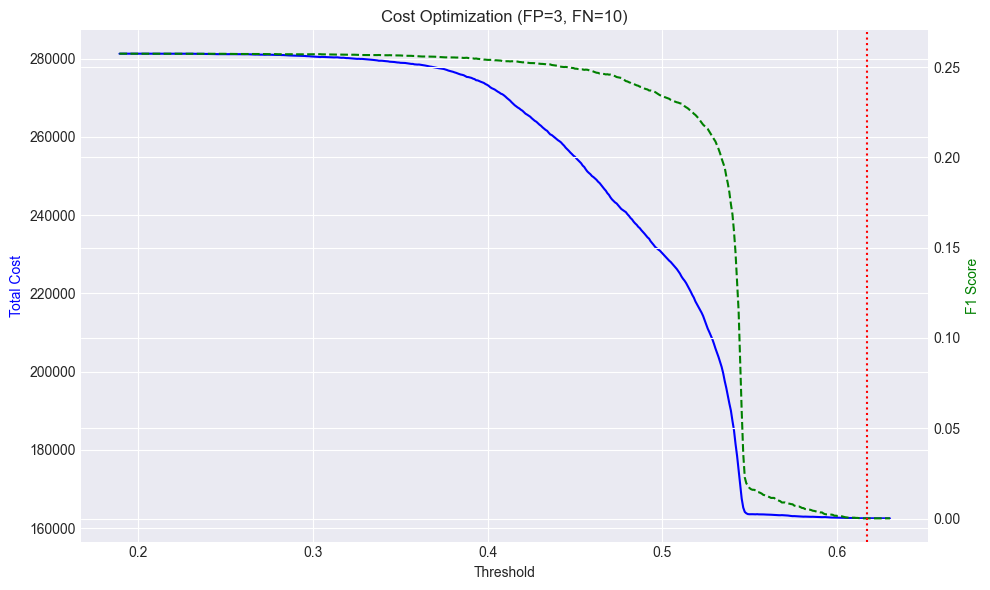

Optimal Threshold: 0.617
Max F1 Score at this Threshold: 0.000
Optimal threshold: 0.617
Minimum cost: 162510.00

Performance at optimal threshold:
              precision    recall  f1-score   support

      Normal       0.85      1.00      0.92     93741
      Crisis       1.00      0.00      0.00     16252

    accuracy                           0.85    109993
   macro avg       0.93      0.50      0.46    109993
weighted avg       0.87      0.85      0.78    109993



In [75]:
def optimize_threshold(model, X_val, y_val, cost_fp=3, cost_fn=10):
    """
    Find optimal classification threshold considering costs
    """
    # Get probability predictions
    y_prob = model.predict_proba(X_val)[:, 1]

    # Test different thresholds
    thresholds = np.linspace(y_prob.min(), y_prob.max(), 500)
    costs = []
    f1_scores = []
    from sklearn.metrics import f1_score

    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)

        # Calculate confusion matrix elements
        fp = np.sum((y_pred == 1) & (y_val == 0))
        fn = np.sum((y_pred == 0) & (y_val == 1))

        # Calculate total cost
        total_cost = (fp * cost_fp) + (fn * cost_fn)
        costs.append(total_cost)

        f1_scores.append(f1_score(y_val, y_pred))


    costs_smooth = np.convolve(costs, np.ones(10)/10, mode='same')
    # Find optimal threshold
    opt_cost_idx = np.argmin(costs)
    opt_f1_idx = np.argmax(f1_scores)

    optimal_threshold = thresholds[opt_cost_idx]

    # Visualize
    fig, ax1 = plt.subplots(figsize=(10, 6))

    ax1.plot(thresholds, costs, color='blue', label='Total Cost')
    ax1.set_xlabel('Threshold')
    ax1.set_ylabel('Total Cost', color='blue')


    ax2 = ax1.twinx()
    ax2.plot(thresholds, f1_scores, color='green', linestyle='--', label='F1 Score')
    ax2.set_ylabel('F1 Score', color='green')

    plt.axvline(optimal_threshold, color='red', linestyle=':',
                label=f'Optimal Threshold: {optimal_threshold:.3f}')

    plt.title(f'Cost Optimization (FP={cost_fp}, FN={cost_fn})')
    fig.tight_layout()
    plt.show()

    print(f"Optimal Threshold: {optimal_threshold:.3f}")
    print(f"Max F1 Score at this Threshold: {f1_scores[opt_cost_idx]:.3f}")

    print(f"Optimal threshold: {optimal_threshold:.3f}")
    print(f"Minimum cost: {costs[opt_cost_idx]:.2f}")

    # Performance at optimal threshold
    y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

    from sklearn.metrics import classification_report
    print("\nPerformance at optimal threshold:")
    print(classification_report(y_val, y_pred_optimal,
                               target_names=['Normal', 'Crisis']))

    return optimal_threshold

# Example usage
optimal_threshold = optimize_threshold(rf_model, X_val_rf_numeric, y_val_rf)


####Clearly Our optimization is a bit off. It's way too sensitive right now so we wont be able to use it. We'll use something closer to the middle. In this case I use .498 as the threshold as that had the best results.

In [76]:
# 1. See what probabilities your model is actually outputting
y_prob = rf_model.predict_proba(X_val_rf_numeric)[:, 1]
print(f"Min Prob: {y_prob.min():.4f}")
print(f"Max Prob: {y_prob.max():.4f}")
print(f"Average Prob: {y_prob.mean():.4f}")

# 2. Pick a threshold right in the middle of that Min and Max
# For example, if Max is 0.3, try 0.2
manual_threshold = (y_prob.max() + y_prob.min()) / 2
print(f"\n--- Testing Manual Threshold: {manual_threshold:.3f} ---")

Min Prob: 0.1893
Max Prob: 0.6301
Average Prob: 0.4924

--- Testing Manual Threshold: 0.410 ---


This code shows us a closer threshold, from there I kept tweaking it till I got .498 as the threshold which was the best I could get.

##Section 9 of Unit 13: Evaluation Implementation and Interpretation  

Classification Report:
              precision    recall  f1-score   support

      Normal      0.846     0.411     0.553     93038
      Crisis      0.154     0.588     0.244     16955

    accuracy                          0.439    109993
   macro avg      0.500     0.500     0.399    109993
weighted avg      0.739     0.439     0.506    109993



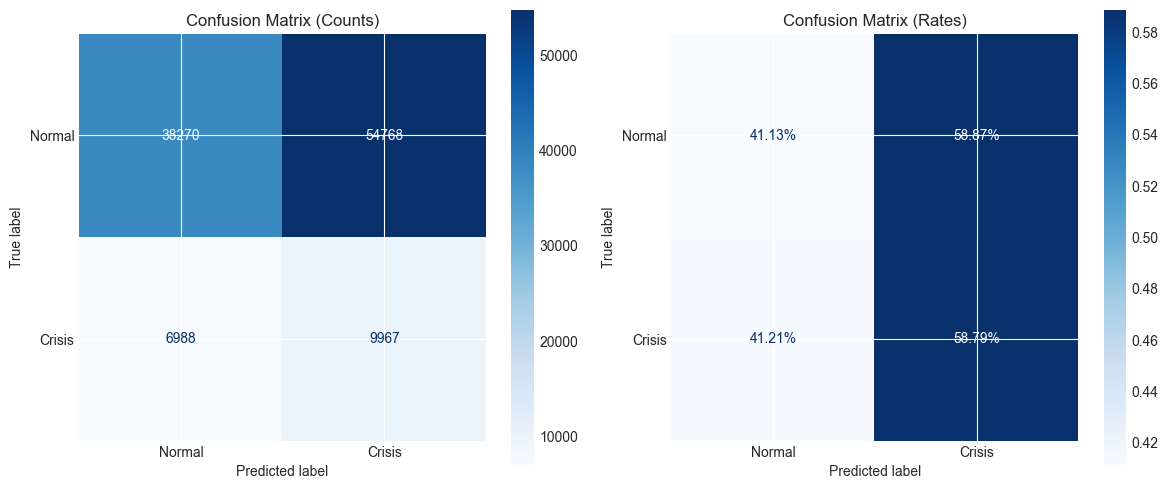


Operational Metrics:
Total test periods: 109993
Actual crises: 16955 (15.4%)
Predicted crises: 64735 (58.9%)

True Positives (Correctly predicted crises): 9967
False Positives (False alarms): 54768
False Negatives (Missed crises): 6988
True Negatives (Correctly predicted normal): 38270

When we predict crisis, we're right 15.4% of the time
We catch 58.8% of actual crises
We have 58.9% false alarm rate

Top 10 Most Important Features:
traffic_volatility: 0.183
page_baseline: 0.133
monthly_deviation: 0.107
surge_momentum: 0.099
dow_sin: 0.071
dow_cos: 0.071
lag_1: 0.067
roll_mean_7: 0.063
lag_7: 0.059
weekend_intensity: 0.037


In [79]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_crisis_classifier(model, X_test, y_test, threshold):
    """
    Comprehensive evaluation for imbalanced crisis detection
    """
    # Get predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    # Classification report
    print("Classification Report:")
    print("="*50)
    report = classification_report(y_test, y_pred,
                                 target_names=['Normal', 'Crisis'],
                                 digits=3)
    print(report)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Raw counts
    disp1 = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Crisis'])
    disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
    axes[0].set_title('Confusion Matrix (Counts)')

    # Normalized
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    disp2 = ConfusionMatrixDisplay(cm_normalized, display_labels=['Normal', 'Crisis'])
    disp2.plot(ax=axes[1], cmap='Blues', values_format='.2%')
    axes[1].set_title('Confusion Matrix (Rates)')

    plt.tight_layout()
    plt.show()

    # Operational interpretation
    tn, fp, fn, tp = cm.ravel()

    print("\nOperational Metrics:")
    print("="*50)
    print(f"Total test periods: {len(y_test)}")
    print(f"Actual crises: {np.sum(y_test)} ({np.sum(y_test)/len(y_test)*100:.1f}%)")
    print(f"Predicted crises: {np.sum(y_pred)} ({np.sum(y_pred)/len(y_test)*100:.1f}%)")
    print()
    print(f"True Positives (Correctly predicted crises): {tp}")
    print(f"False Positives (False alarms): {fp}")
    print(f"False Negatives (Missed crises): {fn}")
    print(f"True Negatives (Correctly predicted normal): {tn}")
    print()
    print(f"When we predict crisis, we're right {tp/(tp+fp)*100:.1f}% of the time")
    print(f"We catch {tp/(tp+fn)*100:.1f}% of actual crises")
    print(f"We have {fp/(fp+tn)*100:.1f}% false alarm rate")

    # Feature importance
    feature_importance = pd.DataFrame({
        'feature': X_test.columns,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    print("\nTop 10 Most Important Features:")
    print("="*50)
    for idx, row in feature_importance.iterrows():
        print(f"{row['feature']}: {row['importance']:.3f}")

    return cm, report

# Example usage
cm, report = evaluate_crisis_classifier(rf_model, X_test_rf_numeric, y_test_rf, .498)


##Section 10: Operational Alert System

In [55]:
def create_alert_system(model, threshold):
    """
    Operational alert system for crisis predictions
    """

    class CrisisAlertSystem:
        def __init__(self, model, threshold):
            self.model = model
            self.threshold = threshold
            self.alert_log = []

        def check_for_crisis(self, current_features):
            """
            Evaluate current conditions for crisis risk
            """
            # Get prediction and probability
            crisis_prob = self.model.predict_proba([current_features])[0, 1]
            is_crisis = crisis_prob >= self.threshold

            # Determine alert level
            if crisis_prob >= 0.8:
                alert_level = "CRITICAL"
                action = "Immediate intervention required"
            elif crisis_prob >= self.threshold:
                alert_level = "WARNING"
                action = "Prepare contingency measures"
            elif crisis_prob >= 0.3:
                alert_level = "WATCH"
                action = "Monitor closely"
            else:
                alert_level = "NORMAL"
                action = "Continue standard operations"

            # Get top contributing factors
            feature_values = pd.Series(current_features, index=X_train_rf_numeric.columns)
            feature_importance = pd.Series(
                self.model.feature_importances_,
                index=X_train_rf_numeric.columns
            )

            # Calculate weighted contributions
            contributions = (feature_values * feature_importance).sort_values(ascending=False)
            top_factors = contributions.head(5)

            # Create alert
            alert = {
                'timestamp': pd.Timestamp.now(),
                'probability': crisis_prob,
                'alert_level': alert_level,
                'action': action,
                'top_factors': top_factors.to_dict(),
                'is_crisis': is_crisis
            }

            # Log alert
            self.alert_log.append(alert)

            return alert

        def display_alert(self, alert):
            """
            Display alert to operators
            """
            print("\n" + "="*60)
            print(f"CRISIS DETECTION ALERT - {alert['timestamp']}")
            print("="*60)
            print(f"Alert Level: {alert['alert_level']}")
            print(f"Crisis Probability: {alert['probability']:.1%}")
            print(f"Recommended Action: {alert['action']}")
            print("\nTop Contributing Factors:")
            for factor, value in alert['top_factors'].items():
                print(f"  - {factor}: {value:.3f}")
            print("="*60)

        def generate_report(self):
            """
            Generate alert summary report
            """
            df_alerts = pd.DataFrame(self.alert_log)

            print("\nAlert System Report")
            print("="*60)
            print(f"Total alerts: {len(df_alerts)}")
            print(f"Critical alerts: {(df_alerts['alert_level']=='CRITICAL').sum()}")
            print(f"Warning alerts: {(df_alerts['alert_level']=='WARNING').sum()}")
            print(f"Watch alerts: {(df_alerts['alert_level']=='WATCH').sum()}")
            print(f"Average crisis probability: {df_alerts['probability'].mean():.1%}")

            return df_alerts

    # Initialize system
    alert_system = CrisisAlertSystem(model, threshold)

    # Example: Check current conditions
    current_conditions = X_test_rf_numeric.iloc[-1].values  # Most recent data
    alert = alert_system.check_for_crisis(current_conditions)
    alert_system.display_alert(alert)

    return alert_system

# Example usage
alert_system = create_alert_system(rf_model, .498)



CRISIS DETECTION ALERT - 2026-04-19 23:21:40.895325
Alert Level: WATCH
Crisis Probability: 45.5%
Recommended Action: Monitor closely

Top Contributing Factors:
  - year: 5.911
  - weekofyear: 1.077
  - page_baseline: 1.049
  - day: 0.684
  - lag_1: 0.440
